In [ ]:
import numpy as np
import time

from sklearn.manifold import TSNE
import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
%matplotlib inline

# Implementing SimCLR for CIFAR10 dataset

Inspired by the following [repo](https://github.com/p3i0t/SimCLR-CIFAR10/tree/master).

Let's follow the self-supervised learning paradigm and try to learn meaningful image vectors *without* relying on ground truth class labels.

Let's utilize a simple dataset and a relavtively small convolutional model.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def save_model(save_path: str, model, optimizer, scheduler):
    state_dict = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict':scheduler.state_dict()}
    torch.save(state_dict, save_path)

In [ ]:
class PairDataset(Dataset):
    def __init__(self, dataset):
        super().__init__()
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img0, lbl0 = self.dataset[idx]
        img1, _ = self.dataset[idx]

        return img0, img1, lbl0

In [ ]:
def set_seed(seed = 16):
    np.random.seed(seed)
    torch.manual_seed(seed)

In [ ]:
preproc_transforms = [
    transforms.ToTensor(),
]

scale_color_transforms = 0.5
randomized_transforms = [
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomResizedCrop(
        size=32,
        ratio=(0.8,1.0),
    ),
    transforms.Compose([
        transforms.RandomApply([
            transforms.ColorJitter(
                brightness=0.8*scale_color_transforms,
                contrast=0.8*scale_color_transforms,
                saturation=0.8*scale_color_transforms,
                hue=0.2*scale_color_transforms
                )
            ],
            p = 0.8),
        transforms.RandomGrayscale(p=0.2)
    ])
]
train_transforms = transforms.Compose(preproc_transforms + randomized_transforms)
test_transforms = transforms.Compose(preproc_transforms)
tensor_normalize = transforms.Normalize(mean=0.5, std=0.25)

In [ ]:
train_batch_size = 512
data_train = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=train_transforms
)
pair_data_train = PairDataset(dataset=data_train)
train_loader = torch.utils.data.DataLoader(pair_data_train, batch_size=train_batch_size, shuffle=True, num_workers=6, drop_last=True)

data_test = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=train_transforms
)
pair_data_test = PairDataset(dataset=data_test)
test_loader = torch.utils.data.DataLoader(pair_data_test, batch_size=238, shuffle=False, num_workers=2, drop_last=True)

class_labels = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

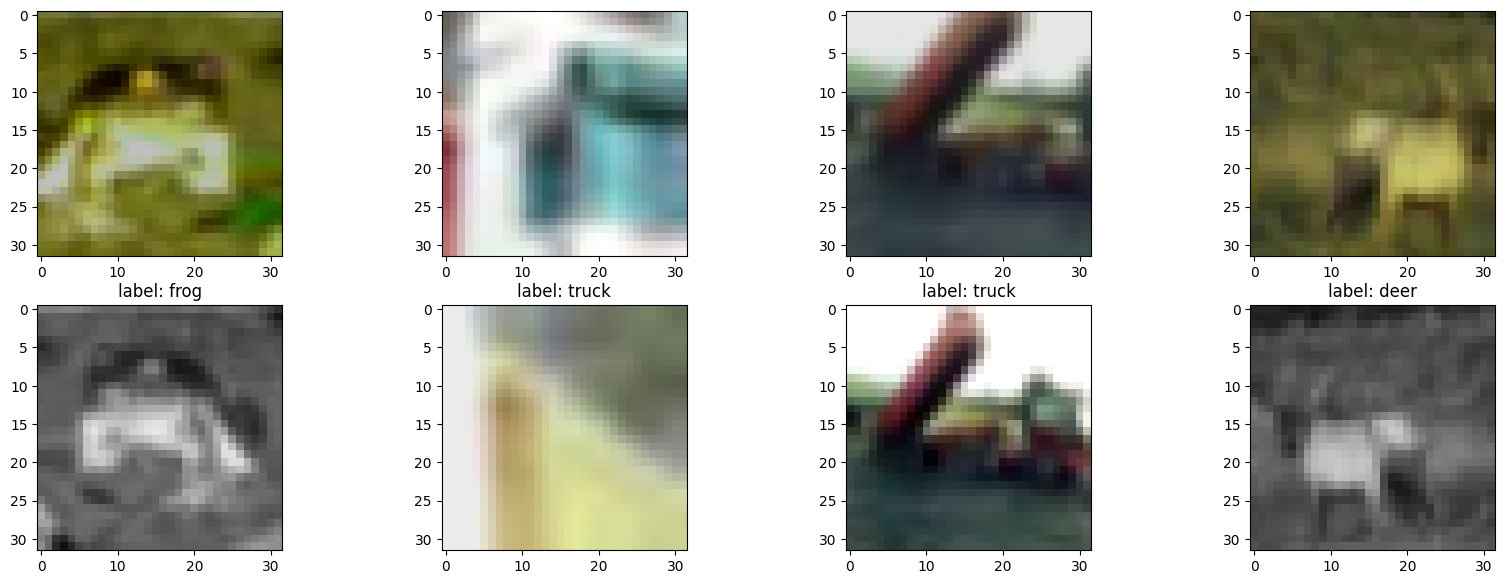

In [ ]:
n_samples = 4
fig, ax = plt.subplots(2, n_samples, figsize=(20, 7))
for idx in range(n_samples):
    img0, img1, lbl0 = pair_data_train[idx]
    ax[0, idx].imshow(img0.permute(1, 2, 0))
    ax[1, idx].imshow(img1.permute(1, 2, 0))
    ax[1, idx].set_title(f"label: {class_labels[lbl0]}")

In [ ]:
img_0, img_1, gt_label = next(iter(train_loader))
img_0.shape

torch.Size([512, 3, 32, 32])

In [ ]:
from torchvision.models.resnet import BasicBlock

class PretrainedModel(nn.Module):
    def __init__(self, proj_dim=128):
        super().__init__()
        self.pretrained = models.efficientnet_b0()
        self.pretrained.features = self.pretrained.features[:-2]

        for p in self.pretrained.parameters():
            p.requires_grad = False

        self.pretrained.features[0][0] = nn.Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        # print(self.pretrained.features)
        self.pretrained.classifier = nn.Identity()
        self.flattener = nn.Flatten()
        self.projector = nn.Sequential(
            nn.Linear(192, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, proj_dim)
        )

    def forward(self,x):
        out = self.pretrained(x)
        emb = self.flattener(out)
        projected = self.projector(emb)
        return projected


class SmallModel(nn.Module):
    def __init__(self, projection_dim=128, embedding_dim=64):
        super().__init__()
        self.maxpool = nn.MaxPool2d(2)
        self.conv_block = nn.Sequential(
            nn.Conv2d(3, 32, (3, 3), stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            self.maxpool
        )
        self.features = nn.Sequential(
            BasicBlock(32, 32),
            nn.Conv2d(32, 64, 1),
            self.maxpool,
            BasicBlock(64, 64),
            self.maxpool,
            BasicBlock(64, 64),
            nn.Conv2d(64, 128, 1),
            self.maxpool,
            BasicBlock(128, 128),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.embedder = nn.Linear(128, embedding_dim)
        self.projector = nn.Sequential(
            nn.ReLU(),
            nn.Linear(embedding_dim, 128, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, projection_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        for m in self.modules():
            if isinstance(m, BasicBlock) and m.bn2.weight is not None:
                nn.init.constant_(m.bn2.weight, 0)  # type: ignore[arg-type]

    def forward_embedding(self, in_tensor):
        x = self.conv_block(in_tensor)
        feats = self.features(x)
        emb = self.embedder(feats)
        return emb

    def forward(self, in_tensor):
        emb = self.forward_embedding(in_tensor)
        projected = self.projector(emb)
        return emb,projected

In [ ]:
model = SmallModel().eval()
sample_tensor = torch.randn((2, 3, 32, 32))
emb, projected = model(sample_tensor)
projected.shape

torch.Size([2, 128])

In [ ]:
class NXEntLoss(nn.Module):
    def __init__(self, temperature: float = 0.5):
        super().__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss(reduction="mean")

    def forward(self, h_full):
        b = h_full.shape[0]
        n = b // 2

        h_full = F.normalize(h_full, dim=1)
        similarity_matrix =  (h_full @ h_full.t()).clamp(min=1e-7)  # normalized cosine similarity scores
        similarity_matrix = similarity_matrix / self.temperature

        # mask positives
        mask = torch.eye(b, dtype=torch.bool, device=h_full.device)

        # ignore diagonal element because it's same object against itself
        logits = similarity_matrix[~mask].view(b, -1)
        # we need positives from sub-matrices
        # | N l_pos |
        # | r_pos N |
        # N - denotes it's negative samples within batch there are no positives there, we can't guarantee it
        l_pos = similarity_matrix[:n, n:]
        r_pos = similarity_matrix[n:, :n]

        # positives are on the diagonals -> form batch of positive logits
        positives = torch.cat([l_pos.diag(), r_pos.diag()], dim=0)
        positives = positives.unsqueeze(1)

        # concatenate them with all the negatives
        logits_with_pos = torch.cat([positives, logits], dim=1)
        labels = torch.zeros(b, device=h_full.device, dtype=torch.long)
        loss = self.criterion(logits_with_pos, labels)
        return loss

In [ ]:
def get_parameter_groups(model, weight_decay=1e-2):
    decay = []
    no_decay = []

    for name, param in model.named_parameters():
        # print(name, param.shape, param.requires_grad)
        if not param.requires_grad:
            continue

        # check if there is '.bias' suffix in parameter name
        # or if the parameter is a 1-dim tensor (usually those are BN scales, shifts or biases)
        if len(param.shape) == 1 or name.endswith(".bias"):
            no_decay.append(param)
        else:
            decay.append(param)

    return [
        {'params': decay, 'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0}
    ]

In [ ]:
# set random seed
set_seed(42)
# set model and optimizer
model = SmallModel(projection_dim=128).to(device)
params = get_parameter_groups(model, weight_decay=1e-6)
optimizer = torch.optim.SGD(
        params,
        lr=0.6,   # lr = 0.1 * batch_size / 256, see section B.6 and B.7 of SimCLR paper.
        momentum=0.9,
        nesterov=True
)

In [ ]:
def get_model_embeddings(model, test_loader, device=torch.device("cpu")):
    # collect all the features and labels for unseen test
    all_labels = []
    all_embeddings = []
    model = model.eval().to(device)
    with torch.no_grad():
        for img0, _, label in test_loader:
            img0 =  img0.to(device)
            emb = model.forward_embedding(img0)
            all_embeddings.append(emb.cpu().numpy())
            all_labels.append(label.numpy())
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_embeddings, all_labels

all_embeddings_init, all_labels = get_model_embeddings(model, test_loader, device=device)

In [ ]:
tsne = TSNE(n_components=2, perplexity = 50)
embeddings_2dim_init = tsne.fit_transform(all_embeddings_init)

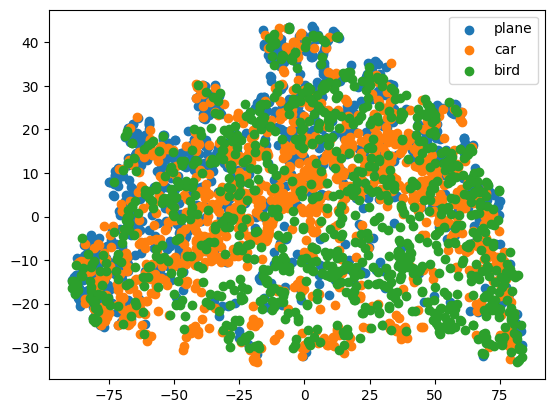

In [ ]:
class_index_list = [0, 1, 2]
for class_idx in class_index_list:
    class_mask = all_labels == class_idx
    plt.scatter(embeddings_2dim_init[class_mask, 0], embeddings_2dim_init[class_mask, 1])
plt.legend([class_labels[class_idx] for class_idx in class_index_list])
plt.show()

In [ ]:
# decay the learning rate with the cosine decay schedule without restarts and with linear warmup
N_WARMUP_EPOCHS = 2
N_EPOCHS = 300
MAX_EPOCH_PLAN = 1000
warmupscheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lambda epoch : (epoch+1)/N_WARMUP_EPOCHS,
)

#SCHEDULER FOR COSINE DECAY
# final LR
min_lr = 1e-3
mainscheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    MAX_EPOCH_PLAN,
    eta_min=min_lr,
    last_epoch=-1
)

In [ ]:
# tmeperature of 0.7 - very strict against negatives, faster convergence, but noisy
# temperature 0.9-1.1 - slow but gradual convergence, less strict against the negatives
criterion = NXEntLoss(temperature=0.5)

In [ ]:
current_epoch = 0
tr_loss = []
val_loss = []
n_iter = 0
for current_epoch in range(N_EPOCHS):
    epoch_prefix = f"Epoch [{current_epoch}/{N_EPOCHS}]\t"
    stime = time.time()

    model.train()
    tr_loss_epoch = 0
    for step, (x_i, x_j, _) in enumerate(train_loader):
        optimizer.zero_grad()
        x_i = x_i.to(device, non_blocking=True)
        x_j = x_j.to(device, non_blocking=True)

        # pass both objects through the model
        _, h_i = model(tensor_normalize(x_i))
        _, h_j = model(tensor_normalize(x_j))
        h_concat = torch.cat([h_i, h_j], dim=0)
        loss = criterion(h_concat)

        loss.backward()
        optimizer.step()
        tr_loss_epoch += loss.item()

    if current_epoch < N_WARMUP_EPOCHS:
        warmupscheduler.step()
    else:
        mainscheduler.step()

    lr = optimizer.param_groups[0]["lr"]
    train_avg_loss = tr_loss_epoch / len(train_loader)
    tr_loss.append(train_avg_loss)
    per_epoch_time = (time.time()-stime)/60.0
    if current_epoch % 50 == 0:
        save_model(f"cifar10_simclr_resnet-custom_epoch{current_epoch}.ckpt", model, optimizer, mainscheduler)

    print(epoch_prefix + f"train loss: {tr_loss[-1]:.4f}  current lr: {lr:.5f} | time {per_epoch_time:.1f} min")

Epoch [0/300]	train loss: 6.2993  current lr: 0.60000 | time 0.1 min
Epoch [1/300]	train loss: 6.0794  current lr: 0.90000 | time 0.1 min
Epoch [2/300]	train loss: 6.0080  current lr: 0.60000 | time 0.1 min
Epoch [3/300]	train loss: 5.9397  current lr: 0.59999 | time 0.1 min
Epoch [4/300]	train loss: 5.9077  current lr: 0.59999 | time 0.1 min
Epoch [5/300]	train loss: 5.8855  current lr: 0.59998 | time 0.1 min
Epoch [6/300]	train loss: 5.8694  current lr: 0.59996 | time 0.1 min
Epoch [7/300]	train loss: 5.8552  current lr: 0.59995 | time 0.1 min
Epoch [8/300]	train loss: 5.8423  current lr: 0.59993 | time 0.1 min
Epoch [9/300]	train loss: 5.8298  current lr: 0.59991 | time 0.1 min
Epoch [10/300]	train loss: 5.8199  current lr: 0.59988 | time 0.1 min
Epoch [11/300]	train loss: 5.8116  current lr: 0.59985 | time 0.1 min
Epoch [12/300]	train loss: 5.8022  current lr: 0.59982 | time 0.1 min
Epoch [13/300]	train loss: 5.7955  current lr: 0.59979 | time 0.1 min
Epoch [14/300]	train loss: 5.7

In [ ]:
save_model(f"cifar10_simclr_resnet-custom_epoch{current_epoch}.ckpt", model, optimizer, mainscheduler)

In [ ]:
full_state = torch.load("cifar10_simclr_resnet-custom_epoch299.ckpt")
model.load_state_dict(full_state['model_state_dict'])

<All keys matched successfully>

In [ ]:
all_embeddings, all_labels = get_model_embeddings(model, test_loader, device=device)

In [ ]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity = 50)
embeddings_2dim = tsne.fit_transform(all_embeddings)

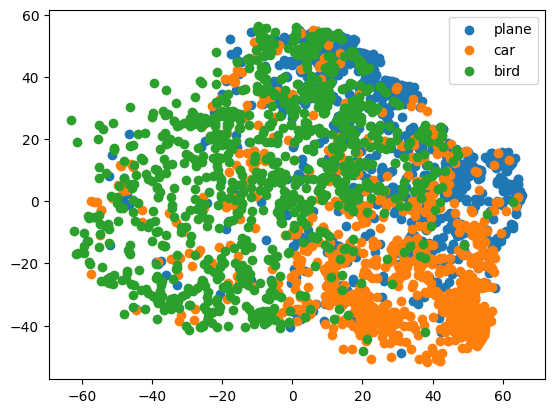

In [ ]:
class_index_list = [0, 1, 2]
for class_idx in class_index_list:
    class_mask = all_labels == class_idx
    plt.scatter(embeddings_2dim[class_mask, 0], embeddings_2dim[class_mask, 1])
plt.legend([class_labels[class_idx] for class_idx in class_index_list])
plt.show()

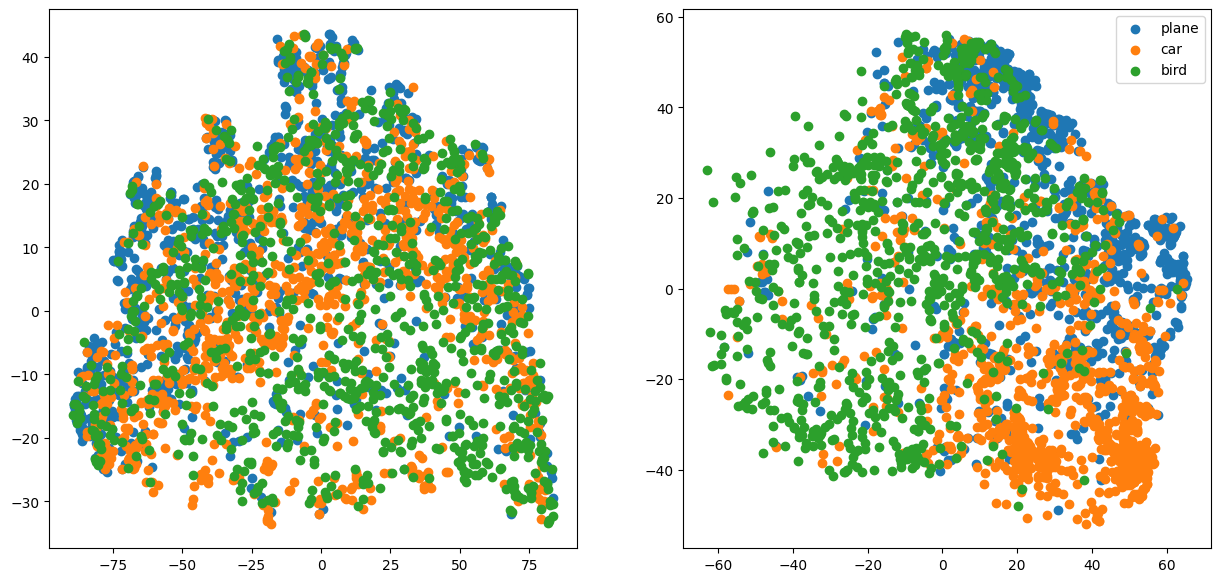

In [ ]:
# and now compare initial and final embeddings
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
class_index_list = [0, 1, 2]
for class_idx in class_index_list:
    class_mask = all_labels == class_idx
    ax[0].scatter(embeddings_2dim_init[class_mask, 0], embeddings_2dim_init[class_mask, 1])
    ax[1].scatter(embeddings_2dim[class_mask, 0], embeddings_2dim[class_mask, 1])
plt.legend([class_labels[class_idx] for class_idx in class_index_list])
plt.show()